In [6]:
!pip install sympy -q

import os
import re
import pickle
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict, defaultdict
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import sympy as sp


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [7]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories
os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./plots', exist_ok=True)
DATA_DIR = "./data/processed"
os.makedirs(DATA_DIR, exist_ok=True)

Using device: cuda


In [8]:
class AmplitudeTokenizer:
    def __init__(self, index_pool_size=1000, special_symbols=None, to_replace=True):
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace

        if special_symbols is None:
            self.special_symbols = [
                '<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>',
                '<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'
            ]
        else:
            self.special_symbols = special_symbols

        self.index_pool = [f"INDEX_{i}" for i in range(index_pool_size)]
        self.particle_index_pool = [f"PINDEX_{i}" for i in range(index_pool_size)]

        self.pattern_particle = re.compile(r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)')
        self.pattern_num_123 = re.compile(r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b')
        self.pattern_momentum = re.compile(r'[ps]_(\d+)')

    @staticmethod
    def remove_whitespace(text):
        return re.sub(r'\s+', '', text)

    @staticmethod
    def split_expression(text):
        return re.split(r' ', text)

    def normalize_indices(self, text):
        if not self.to_replace:
            return text

        text = self.remove_whitespace(text)
        text = re.sub(r'\bs_(\d{2,})\b', lambda m: f'__MAND_{m.group(1)}__', text)
        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r'\bs_(\d+)\b', r'MOMENTUM_\1', text)
        text = re.sub(r'__MAND_(\d+)__', r's_\1', text)
        text = text.replace('\\\\', '\\').replace('\\', r' \\ ').replace('%', ' % ')

        index_matches = list(OrderedDict.fromkeys(self.pattern_num_123.findall(text)))
        index_iter = iter(self.index_pool)
        index_mapping = {}
        for match in index_matches:
            try:
                index_mapping[match] = next(index_iter)
            except StopIteration:
                raise RuntimeError(f"Index pool exhausted")

        for old, new in sorted(index_mapping.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        particle_matches = list(OrderedDict.fromkeys(
            m.group('target')
            for m in sorted(self.pattern_particle.finditer(text), key=lambda m: m.start())
        ))

        particle_iter = iter(self.particle_index_pool)
        particle_mapping = {}
        for match in particle_matches:
            try:
                particle_mapping[match] = next(particle_iter)
            except StopIteration:
                raise RuntimeError("Particle index pool exhausted")

        for old, new in sorted(particle_mapping.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        return text

    def tokenize_amplitude(self, amplitude_text):
        if self.to_replace:
            text = self.normalize_indices(amplitude_text)
        else:
            text = amplitude_text

        text = self.remove_whitespace(text)
        text = text.replace('\\\\', '\\').replace('\\', r' \\ ').replace('%', ' % ')
        text = text.replace("(*)", " CONJ ")
        text = text.replace("(theta_W)", "_theta_W")

        for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
            text = text.replace(symbol, f' {symbol} ')

        text = text.replace("_PINDEX", "_ PINDEX").replace("_INDEX", "_ INDEX")
        text = text.replace("reg_prop", " reg_prop ")
        text = re.sub(r' {2,}', ' ', text)

        tokens = [t for t in self.split_expression(text) if t]
        tokens = self.tag_mandelstam(tokens)
        return tokens

    def tokenize_squared(self, squared_text):
        if self.to_replace:
            protected = re.sub(r'\bs_(\d{2,})\b',
                              lambda m: f'__MAND_{m.group(1)}__',
                              squared_text)
            text = self.normalize_indices(protected)
            text = re.sub(r'__MAND_(\d+)__', r's_\1', text)
        else:
            text = squared_text

        text = self.remove_whitespace(text)
        text = text.replace("(theta_W)", "_theta_W")

        for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
            text = text.replace(symbol, f' {symbol} ')

        text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)
        text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)
        text = text.replace("reg_prop", " reg_prop ")
        text = re.sub(r' {2,}', ' ', text)

        tokens = [t for t in self.split_expression(text) if t]
        tokens = self.tag_mandelstam(tokens)
        return tokens

    def tag_mandelstam(self, tokens):
        mandelstam_map = {
            's_12': '<S>',       's_21': '<S>',
            's_13': '<T>',       's_31': '<T>',
            's_14': '<U>',       's_41': '<U>',
            's_23': '<U_CROSS>', 's_32': '<U_CROSS>',
            's_24': '<T_CROSS>', 's_42': '<T_CROSS>',
            's_34': '<S_CROSS>', 's_43': '<S_CROSS>',
        }
        return [mandelstam_map.get(tok, tok) for tok in tokens]

    def get_token_types(self, tokens):
        MOMENTUM_TOKENS = {'<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'}
        SPECIAL_TOKENS = {'<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>'}

        type_labels = []
        for tok in tokens:
            if tok in MOMENTUM_TOKENS or tok.startswith('MOMENTUM_'):
                type_labels.append(0)
            elif tok.startswith('m_') or tok == 'reg_prop':
                type_labels.append(1)
            elif any(x in tok for x in ['gamma', 'sigma', 'eta', 'eps', 'del',
                                         'tau', 'mu', 'rho', 'gam', 'vho', 'CONJ',
                                         'T_C', 'G_{']):
                type_labels.append(2)
            elif tok.startswith('INDEX_') or tok.startswith('PINDEX_'):
                type_labels.append(3)
            elif tok in SPECIAL_TOKENS:
                type_labels.append(5)
            else:
                type_labels.append(4)
        return type_labels

    def tokenize_with_types(self, amplitude_text):
        tokens = self.tokenize_amplitude(amplitude_text)
        types = self.get_token_types(tokens)
        return tokens, types

Vocabulary

In [9]:
class Vocabulary:
    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=[5,6]):

        tokens = list(tokens)
        for special in special_symbols:
            if special in tokens:
                tokens.remove(special)

        self.token_list = special_symbols + tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.token_list)}
        self.idx_to_token = {idx: token for token, idx in self.token_to_idx.items()}

        self.pad_idx = pad_idx
        self.unk_idx = unk_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.sep_idx = sep_idx
        self.term_idx = term_idx

        self.pad_tok = special_symbols[pad_idx]
        self.unk_tok = special_symbols[unk_idx]
        self.bos_tok = special_symbols[bos_idx]
        self.eos_tok = special_symbols[eos_idx]
        self.sep_tok = special_symbols[sep_idx]

        self.special_indices = set(self.token_to_idx[sym] for sym in special_symbols)

    def encode(self, tokens):
        return [self.token_to_idx.get(token, self.unk_idx) for token in tokens]

    def decode(self, indices, include_special=True):
        if include_special:
            return [self.idx_to_token.get(idx, self.unk_tok) for idx in indices]
        else:
            return [
                self.idx_to_token.get(idx, self.unk_tok)
                for idx in indices
                if idx not in self.special_indices or idx == self.sep_idx
            ]

    def __len__(self):
        return len(self.token_list)

    def __getitem__(self, item):
        if isinstance(item, int):
            return self.idx_to_token.get(item, self.unk_tok)
        return self.token_to_idx.get(item, self.unk_idx)

    def tokens(self):
        return self.token_list

In [10]:
DATA_PATH = '/content/data/processed/processed_data2.pkl'

with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

# Extract QCD data
qcd_train = data['qcd']['train']
qcd_val = data['qcd']['val']
qcd_test = data['qcd']['test']

# Extract vocabularies from QCD data
qcd_src_vocab = data['qcd']['src_vocab']
qcd_tgt_vocab = data['qcd']['tgt_vocab']

print(f"QCD Train: {len(qcd_train)} samples")
print(f"QCD Val: {len(qcd_val)} samples")
print(f"QCD Test: {len(qcd_test)} samples")
print(f"QCD Source vocabulary size: {len(qcd_src_vocab)}")
print(f"QCD Target vocabulary size: {len(qcd_tgt_vocab)}")

QCD Train: 187 samples
QCD Val: 23 samples
QCD Test: 24 samples
QCD Source vocabulary size: 138
QCD Target vocabulary size: 67


Unified Vocab

In [11]:
class UnifiedVocabulary:
    def __init__(self, src_vocab, tgt_vocab):
        special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>',
                          '<TERM0>', '<TERM1>', '<S>', '<T>', '<U>',
                          '<S_CROSS>', '<T_CROSS>', '<U_CROSS>']

        all_tokens = []
        seen = set()

        for tok in special_tokens:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        for tok in src_vocab.token_list:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        for tok in tgt_vocab.token_list:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        self.token_list = all_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(all_tokens)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}

        self.pad_idx = self.token_to_idx.get('<PAD>', 0)
        self.bos_idx = self.token_to_idx.get('<BOS>', 2)
        self.eos_idx = self.token_to_idx.get('<EOS>', 3)
        self.unk_idx = self.token_to_idx.get('<UNK>', 1)
        self.sep_idx = self.token_to_idx.get('<SEP>', 4)

        print(f"Unified vocabulary size: {len(self.token_list)}")
        print(f"  Source had: {len(src_vocab)}")
        print(f"  Target had: {len(tgt_vocab)}")
        print(f"  Special tokens: {len(special_tokens)}")

    def encode(self, tokens):
        return [self.token_to_idx.get(t, self.unk_idx) for t in tokens]

    def decode(self, indices, include_special=False):
        tokens = [self.idx_to_token.get(i, '<UNK>') for i in indices]
        if not include_special:
            specials = {'<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>',
                       '<TERM0>', '<TERM1>', '<S>', '<T>', '<U>',
                       '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'}
            tokens = [t for t in tokens if t not in specials]
        return tokens

    def __len__(self):
        return len(self.token_list)


unified_vocab = UnifiedVocabulary(qcd_src_vocab, qcd_tgt_vocab)
print(f"\nUsing unified vocabulary with {len(unified_vocab)} tokens")

Unified vocabulary size: 174
  Source had: 138
  Target had: 67
  Special tokens: 13

Using unified vocabulary with 174 tokens


Positional Encoding

In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                            -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

Physics text encoder for QCD same as QED

In [13]:
class PhysicsInformedTextEncoder(nn.Module):
    def __init__(self, vocab_size: int, num_types: int = 6, d_model: int = 512,
                 nhead: int = 8, num_layers: int = 6, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model

        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.type_embed = nn.Embedding(num_types, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, token_ids: torch.Tensor, type_ids: torch.Tensor,
                src_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.token_embed(token_ids) + self.type_embed(type_ids)
        x = x * math.sqrt(self.d_model)
        x = self.pos_encoding(x)

        if src_mask is not None:
            key_padding_mask = src_mask
        else:
            key_padding_mask = (token_ids == 0)

        x = self.encoder(x, src_key_padding_mask=key_padding_mask)
        return self.layer_norm(x)

In [14]:
class PhysicsInformedModel(nn.Module):
    def __init__(self, vocab_size: int, num_types: int = 6, d_model: int = 512,
                 nhead: int = 8, num_layers: int = 6, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size

        self.text_encoder = PhysicsInformedTextEncoder(
            vocab_size, num_types, d_model, nhead, num_layers, dropout
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers)

        self.output_proj = nn.Linear(d_model, vocab_size)

        self.tgt_embed = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)

        self.output_proj.weight = self.text_encoder.token_embed.weight

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src_ids: torch.Tensor, src_types: torch.Tensor,
                tgt_ids: torch.Tensor) -> torch.Tensor:
        src_mask = (src_ids == 0)
        memory = self.text_encoder(src_ids, src_types, src_mask)

        tgt_input = tgt_ids
        tgt_emb = self.tgt_embed(tgt_input) * math.sqrt(self.d_model)
        tgt_emb = self.pos_encoding(tgt_emb)

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_input.size(1)).to(device)

        output = self.decoder(tgt_emb, memory, tgt_mask=tgt_mask)

        logits = self.output_proj(output)

        return logits

Physics Informed Dataset with masking(QCD)

In [15]:
class PhysicsInformedDataset(Dataset):
    def __init__(self, data_list: List[Dict], vocab, max_len: int = 1024, use_physics_masking: bool = True):
        self.data = data_list
        self.vocab = vocab
        self.max_len = max_len
        self.pad_idx = vocab.pad_idx
        self.bos_idx = vocab.bos_idx
        self.eos_idx = vocab.eos_idx
        self.use_physics_masking = use_physics_masking

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict:
        item = self.data[idx]

        amp_tokens = item['amp_tokens']
        amp_types = item['amp_types']
        sq_tokens = item['sq_tokens']

        src_ids = self.vocab.encode(amp_tokens)
        src_type_ids = amp_types

        src_ids = [self.bos_idx] + src_ids + [self.eos_idx]
        src_type_ids = [5] + src_type_ids + [5]

        # Apply physics-informed masking (QCD version)
        if self.use_physics_masking and random.random() < 0.15:
            src_ids, src_type_ids = self._physics_masking(src_ids, src_type_ids)

        tgt_ids = self.vocab.encode(sq_tokens)
        tgt_ids = [self.bos_idx] + tgt_ids + [self.eos_idx]

        src_ids = src_ids[:self.max_len]
        src_type_ids = src_type_ids[:self.max_len]
        tgt_ids = tgt_ids[:self.max_len]

        return {
            'src_ids': torch.tensor(src_ids, dtype=torch.long),
            'src_types': torch.tensor(src_type_ids, dtype=torch.long),
            'tgt_ids': torch.tensor(tgt_ids, dtype=torch.long)
        }

    def _physics_masking(self, src_ids, src_type_ids):
        """QCD-specific physics-informed masking."""
        masked_ids = src_ids.copy()

        # 1. Mask Mandelstam triples together
        mandelstam_tokens = {'<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'}
        mandelstam_positions = []

        for i, idx in enumerate(src_ids):
            token = self.vocab.idx_to_token.get(idx, '')
            if token in mandelstam_tokens:
                mandelstam_positions.append(i)

        if len(mandelstam_positions) >= 3:
            for pos in mandelstam_positions[:3]:
                if random.random() < 0.8:
                    masked_ids[pos] = self.vocab.pad_idx

        # 2. Mask QCD coupling constants with exponents (g, g_s, g^2, g^4)
        coupling_tokens = ['g', 'g_s', 'gs', 'G']
        i = 0
        while i < len(src_ids) - 2:
            token_i = self.vocab.idx_to_token.get(src_ids[i], '')
            token_j = self.vocab.idx_to_token.get(src_ids[i+1], '')
            token_k = self.vocab.idx_to_token.get(src_ids[i+2], '')

            if token_i in coupling_tokens and token_j == '^' and token_k.isdigit():
                if random.random() < 0.5:
                    masked_ids[i] = self.vocab.pad_idx
                    masked_ids[i+1] = self.vocab.pad_idx
                    masked_ids[i+2] = self.vocab.pad_idx
                i += 3
            else:
                i += 1

        return masked_ids, src_type_ids


def collate_fn(batch: List[Dict]) -> Dict:
    src_ids = [item['src_ids'] for item in batch]
    src_types = [item['src_types'] for item in batch]
    tgt_ids = [item['tgt_ids'] for item in batch]

    src_ids_padded = pad_sequence(src_ids, batch_first=True, padding_value=0)
    src_types_padded = pad_sequence(src_types, batch_first=True, padding_value=0)
    tgt_ids_padded = pad_sequence(tgt_ids, batch_first=True, padding_value=0)

    return {
        'src_ids': src_ids_padded,
        'src_types': src_types_padded,
        'tgt_ids': tgt_ids_padded
    }

In [16]:
class PhysicsLossCalculatorQCD:
    def __init__(self, vocab):
        self.vocab = vocab
        # QCD-specific coupling tokens
        self.coupling_tokens = ['g', 'g_s', 'gs', 'G']
        # QCD color factor tokens
        self.color_tokens = ['T_C', 'G_{', 'f_abc']

    def compute_physics_loss(self, logits):

        pred_indices = logits.argmax(dim=-1)
        physics_loss = 0.0


        for batch in pred_indices:
            coupling_power = 0
            i = 0
            while i < len(batch) - 2:
                token_i = self.vocab.idx_to_token.get(batch[i].item(), '')
                token_j = self.vocab.idx_to_token.get(batch[i+1].item(), '')
                token_k = self.vocab.idx_to_token.get(batch[i+2].item(), '')
                if token_i in self.coupling_tokens and token_j == '^' and token_k.isdigit():
                    coupling_power += int(token_k)
                    i += 3
                else:
                    i += 1
            if coupling_power % 2 != 0:
                physics_loss += 0.3


        for batch in pred_indices:
            tokens = [self.vocab.idx_to_token.get(idx.item(), '') for idx in batch]
            has_S = '<S>' in tokens
            has_S_cross = '<S_CROSS>' in tokens
            has_T = '<T>' in tokens
            has_T_cross = '<T_CROSS>' in tokens
            has_U = '<U>' in tokens
            has_U_cross = '<U_CROSS>' in tokens

            if has_S != has_S_cross:
                physics_loss += 0.2
            if has_T != has_T_cross:
                physics_loss += 0.2
            if has_U != has_U_cross:
                physics_loss += 0.2


        for batch in pred_indices:
            tokens = [self.vocab.idx_to_token.get(idx.item(), '') for idx in batch]
            reg_prop_count = tokens.count('reg_prop')
            if reg_prop_count not in [0, 1]:
                physics_loss += 0.2


        for batch in pred_indices:
            tokens = [self.vocab.idx_to_token.get(idx.item(), '') for idx in batch]
            color_count = sum(1 for t in tokens if any(c in t for c in self.color_tokens))
            # Penalizing here for the  odd number of color tokens
            if color_count % 2 != 0:
                physics_loss += 0.25

        return torch.tensor(physics_loss / len(pred_indices),
                           device=logits.device,
                           dtype=torch.float32,
                           requires_grad=True)

Training and validation function

In [17]:
def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer,
                    criterion: nn.Module, device: torch.device, physics_calc) -> Tuple[float, float]:
    model.train()
    total_ce_loss = 0.0
    total_physics_loss = 0.0
    total_tokens = 0

    for batch in loader:
        src_ids = batch['src_ids'].to(device)
        src_types = batch['src_types'].to(device)
        tgt_ids = batch['tgt_ids'].to(device)

        logits = model(src_ids, src_types, tgt_ids)

        tgt_output = tgt_ids[:, 1:]
        logits = logits[:, :-1, :]

        ce_loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        physics_loss = physics_calc.compute_physics_loss(logits)

        # Weight physics loss lower for QCD (0.05)
        loss = ce_loss + 0.05 * physics_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        num_tokens = (tgt_output != 0).sum().item()
        total_ce_loss += ce_loss.item()
        total_physics_loss += physics_loss.item()
        total_tokens += num_tokens

    return (total_ce_loss / max(total_tokens, 1),
            total_physics_loss / len(loader))


In [18]:
@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader, criterion: nn.Module,
             device: torch.device) -> Tuple[float, float]:
    model.eval()
    total_loss = 0
    total_tokens = 0
    total_correct = 0

    for batch in loader:
        src_ids = batch['src_ids'].to(device)
        src_types = batch['src_types'].to(device)
        tgt_ids = batch['tgt_ids'].to(device)

        logits = model(src_ids, src_types, tgt_ids)

        tgt_output = tgt_ids[:, 1:]
        logits = logits[:, :-1, :]

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        preds = logits.argmax(dim=-1)

        mask = (tgt_output != 0)
        correct = (preds == tgt_output) & mask
        total_correct += correct.sum().item()

        num_tokens = mask.sum().item()
        total_loss += loss.item()
        total_tokens += num_tokens

    return (total_loss / max(total_tokens, 1),
            total_correct / max(total_tokens, 1))

Hyperparamters (QCD)

In [19]:
# Model architecture
VOCAB_SIZE = len(unified_vocab)
NUM_TYPES = 6
D_MODEL = 256
NHEAD = 8
NUM_LAYERS = 6
DROPOUT = 0.1
MAX_LEN = 1024         # Longer for QCD (was 512 for QED)

# Training
BATCH_SIZE = 16        # Smaller due to longer sequences
EPOCHS = 50
LEARNING_RATE = 5e-5   # Lower learning rate for fine-tuning is set here
WEIGHT_DECAY = 0.01
PATIENCE = 10

print(f"QCD Model Configuration:")
print(f"  Vocabulary size: {VOCAB_SIZE}")
print(f"  Model dimension: {D_MODEL}")
print(f"  Max sequence length: {MAX_LEN}")
print(f"  Batch size: {BATCH_SIZE}")

QCD Model Configuration:
  Vocabulary size: 174
  Model dimension: 256
  Max sequence length: 1024
  Batch size: 16


Loading the Pretrained Encoder from the QED model and freezing the first two layers

In [21]:
train_dataset = PhysicsInformedDataset(qcd_train, unified_vocab, max_len=MAX_LEN, use_physics_masking=True)
val_dataset = PhysicsInformedDataset(qcd_val, unified_vocab, max_len=MAX_LEN, use_physics_masking=False)
test_dataset = PhysicsInformedDataset(qcd_test, unified_vocab, max_len=MAX_LEN, use_physics_masking=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

model = PhysicsInformedModel(
    vocab_size=VOCAB_SIZE,
    num_types=NUM_TYPES,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT)

pretrained_path = '/content/checkpoints/qed_encoder_pretrained.pt'

if os.path.exists(pretrained_path):
    pretrained_encoder = torch.load(pretrained_path, map_location=device)

    model_state = model.text_encoder.state_dict()

    filtered_state = {}
    skipped_layers = []
    loaded_layers = []

    for name, param in pretrained_encoder.items():
        if name in model_state:
            if model_state[name].shape == param.shape:
                filtered_state[name] = param
                loaded_layers.append(name)
            else:
                skipped_layers.append(f"{name}: QED {param.shape} vs QCD {model_state[name].shape}")
        else:
            skipped_layers.append(f"{name}: not in QCD model")

    model.text_encoder.load_state_dict(filtered_state, strict=False)

    print(f"\n✓ Loaded {len(loaded_layers)} layers from QED pre-trained encoder")
    print(f"  Skipped {len(skipped_layers)} layers due to shape mismatch")

    with torch.no_grad():
        qed_vocab_size = 135
        if VOCAB_SIZE > qed_vocab_size:
            nn.init.xavier_uniform_(model.text_encoder.token_embed.weight[qed_vocab_size:])
            print(f"  Initialized {VOCAB_SIZE - qed_vocab_size} new QCD tokens randomly")

else:
    print(f"⚠ Warning: Pre-trained weights not found at {pretrained_path}")
    print("  Training encoder from scratch")

frozen_count = 0
trainable_count = 0


print("ENCODER LAYER STATUS (Transfer Learning)")


for i, layer in enumerate(model.text_encoder.encoder.layers):
    if i < 2:
        for param in layer.parameters():
            param.requires_grad = False
            frozen_count += param.numel()
        print(f"  Encoder Layer {i+1}: FROZEN (transferring QED knowledge)")
    else:
        for param in layer.parameters():
            param.requires_grad = True
            trainable_count += param.numel()
        print(f"  Encoder Layer {i+1}: TRAINABLE (adapting to QCD)")

for param in model.decoder.parameters():
    param.requires_grad = True
    trainable_count += param.numel()

for param in model.text_encoder.layer_norm.parameters():
    param.requires_grad = True

print(f"\nParameter Summary:")
print(f"  Frozen parameters: {frozen_count:,}")
print(f"  Trainable parameters: {trainable_count:,}")

total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total trainable parameters: {total_trainable_params:,}")

physics_calc = PhysicsLossCalculatorQCD(unified_vocab)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')

model = model.to(device)
print(f"\n✓ Model moved to: {next(model.parameters()).device}")

best_val_loss = float('inf')
patience_counter = 0
best_state = None

Train batches: 12
Val batches: 2
Test batches: 2

✓ Loaded 76 layers from QED pre-trained encoder
  Skipped 1 layers due to shape mismatch
  Initialized 39 new QCD tokens randomly
ENCODER LAYER STATUS (Transfer Learning)
  Encoder Layer 1: FROZEN (transferring QED knowledge)
  Encoder Layer 2: FROZEN (transferring QED knowledge)
  Encoder Layer 3: TRAINABLE (adapting to QCD)
  Encoder Layer 4: TRAINABLE (adapting to QCD)
  Encoder Layer 5: TRAINABLE (adapting to QCD)
  Encoder Layer 6: TRAINABLE (adapting to QCD)

Parameter Summary:
  Frozen parameters: 1,579,520
  Trainable parameters: 9,479,680
  Total trainable parameters: 9,570,990

✓ Model moved to: cuda:0


QCD Model Training

In [22]:
train_losses = []
val_losses = []
val_accuracies = []
train_physics_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_physics_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device, physics_calc
    )
    scheduler.step()

    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    train_physics_losses.append(train_physics_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, './checkpoints/qcd_finetuned_best.pt')
        improved = "★"
    else:
        patience_counter += 1
        improved = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
              f"Physics Loss: {train_physics_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {improved}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Load best model
if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"\n✓ Loaded best QCD model (val_loss: {best_val_loss:.4f})")

# Save the fine-tuned encoder for future use
torch.save(model.text_encoder.state_dict(), './checkpoints/qcd_encoder_finetuned.pt')
print("✓ Fine-tuned QCD encoder saved to ./checkpoints/qcd_encoder_finetuned.pt")

Epoch   1/50 | Train Loss: 3.8340 | Physics Loss: 0.0526 | Val Loss: 3.1209 | Val Acc: 0.2558 ★
Epoch   5/50 | Train Loss: 1.5280 | Physics Loss: 0.5127 | Val Loss: 1.4813 | Val Acc: 0.5640 ★
Epoch  10/50 | Train Loss: 1.2292 | Physics Loss: 0.5092 | Val Loss: 1.2373 | Val Acc: 0.5871 ★
Epoch  15/50 | Train Loss: 1.1035 | Physics Loss: 0.5026 | Val Loss: 1.0768 | Val Acc: 0.6285 ★
Epoch  20/50 | Train Loss: 0.9672 | Physics Loss: 0.5403 | Val Loss: 0.9591 | Val Acc: 0.6636 ★
Epoch  25/50 | Train Loss: 0.8807 | Physics Loss: 0.5281 | Val Loss: 0.8567 | Val Acc: 0.6953 ★
Epoch  30/50 | Train Loss: 0.8364 | Physics Loss: 0.5262 | Val Loss: 0.7964 | Val Acc: 0.7149 
Epoch  35/50 | Train Loss: 0.7858 | Physics Loss: 0.5206 | Val Loss: 0.7702 | Val Acc: 0.7303 
Epoch  40/50 | Train Loss: 0.7564 | Physics Loss: 0.5147 | Val Loss: 0.7321 | Val Acc: 0.7386 ★
Epoch  45/50 | Train Loss: 0.7440 | Physics Loss: 0.5225 | Val Loss: 0.7203 | Val Acc: 0.7464 ★
Epoch  50/50 | Train Loss: 0.7423 | Physic

Plotting the training curves

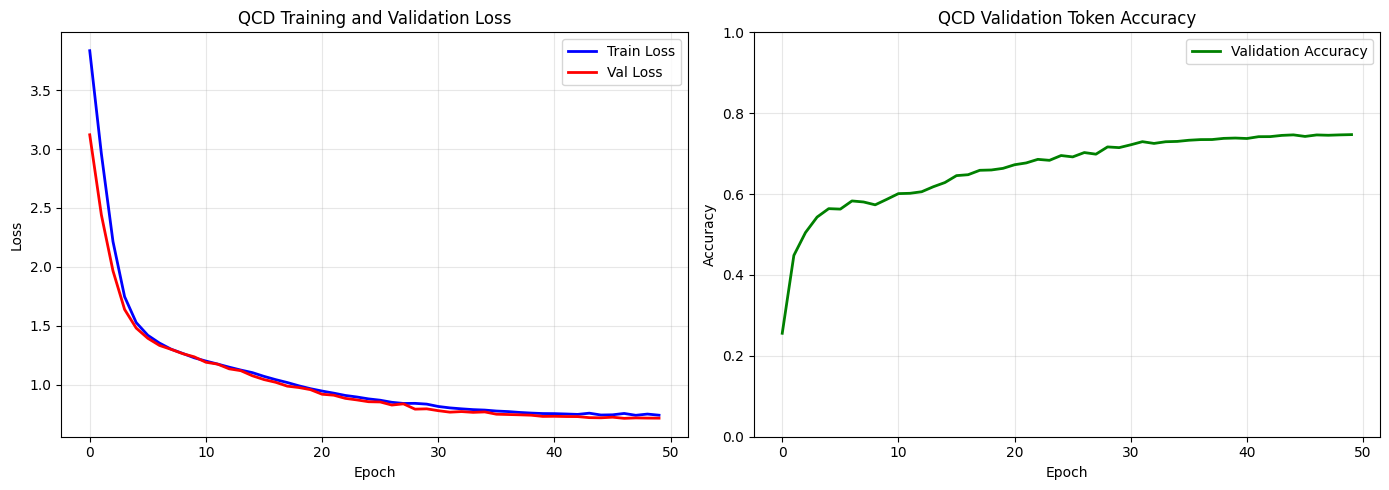

✓ QCD training curves saved to ./plots/qcd_training_curves.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('QCD Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(val_accuracies, label='Validation Accuracy', color='green', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('QCD Validation Token Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('./plots/qcd_training_curves.png', dpi=150)
plt.show()
print("✓ QCD training curves saved to ./plots/qcd_training_curves.png")

Test Evaluation QCD

In [25]:
test_loss, test_acc = validate(model, test_loader, criterion, device)

print("QCD TEST SET RESULTS")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Token Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


# Save results
results = {
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'best_val_loss': best_val_loss,
    'final_val_accuracy': val_accuracies[-1] if val_accuracies else 0,
    'epochs_trained': len(train_losses)
}

print("\nQCD Training Summary:")
print(f"  Best Validation Loss: {best_val_loss:.4f}")
print(f"  Final Validation Accuracy: {val_accuracies[-1]*100:.2f}%" if val_accuracies else "  N/A")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Total Epochs Trained: {len(train_losses)}")

QCD TEST SET RESULTS
Test Loss: 0.6705
Test Token Accuracy: 0.7581 (75.81%)

QCD Training Summary:
  Best Validation Loss: 0.7158
  Final Validation Accuracy: 74.71%
  Test Accuracy: 75.81%
  Total Epochs Trained: 50
